In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [91]:
data = pd.read_csv("dataset/spam.csv")

data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [92]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [93]:
data.columns = ['label','message']

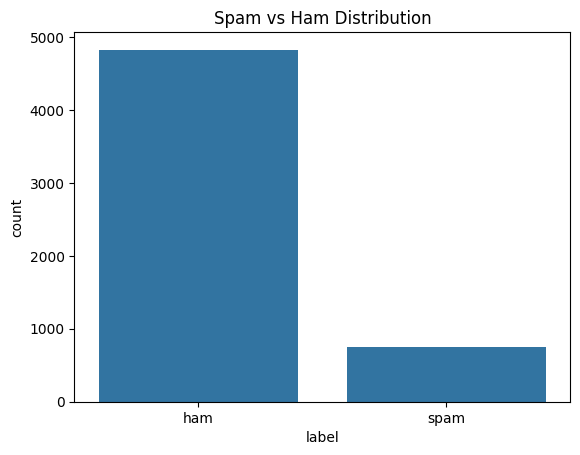

In [94]:
sns.countplot(x='label', data=data)
plt.title("Spam vs Ham Distribution")
plt.show()

In [95]:
data['label'] = data['label'].map({
    'ham':0,
    'spam':1
})

In [97]:
def clean_text(text):

    text = text.lower()

    text = re.sub('[^a-zA-Z]', ' ', text)

    text = text.split()

    text = " ".join(text)

    return text

In [98]:
data['message'] = data['message'].apply(clean_text)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    data['message'],
    data['label'],
    test_size=0.2,
    random_state=42
)

In [100]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

tokenizer.fit_on_texts(X_train_clean)
X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

In [101]:
max_len = 150

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)

X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [102]:
model = tf.keras.Sequential([

    tf.keras.layers.Embedding(50000,128,input_length=max_len),

    tf.keras.layers.Conv1D(128,5,activation='relu'),

    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dense(64,activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1,activation='sigmoid')
])

c:\Users\anuru\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [103]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [104]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.8940 - loss: 0.2778 - val_accuracy: 0.9753 - val_loss: 0.1081
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9874 - loss: 0.0570 - val_accuracy: 0.9798 - val_loss: 0.0785
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9753 - val_loss: 0.1126
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 1.0000 - loss: 7.1399e-04 - val_accuracy: 0.9776 - val_loss: 0.1200
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 1.0000 - loss: 2.8847e-04 - val_accuracy: 0.9765 - val_loss: 0.1279


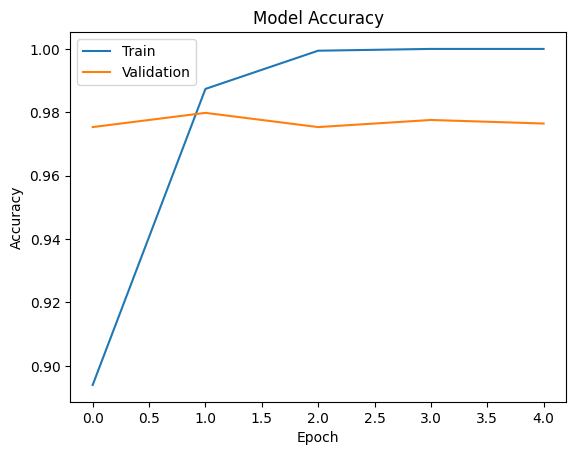

In [105]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

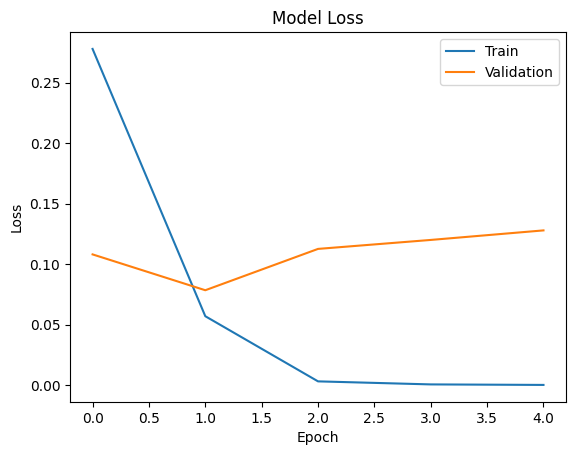

In [106]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [107]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9883 - loss: 0.0643
Test Accuracy: 0.9883407950401306


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


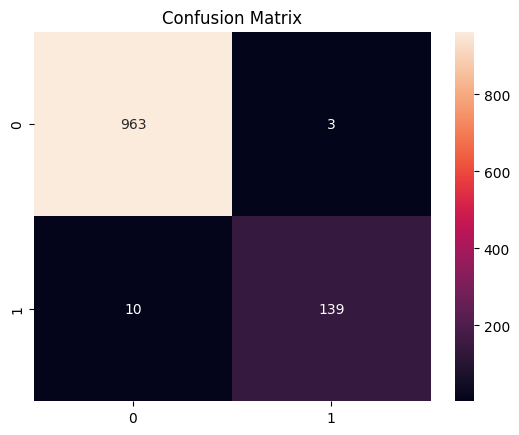

In [108]:
y_pred = model.predict(X_test_pad)

y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [109]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [110]:
def predict_spam(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_len)

    prob = model.predict(padded)[0][0]

    print("Spam Probability:", prob)

    if prob > 0.4:
        print("Spam")
    else:
        print("Ham")

In [ ]:
c

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Spam Probability: 0.930475
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Spam Probability: 0.99874246
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Spam Probability: 0.9997754
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Spam Probability: 2.2456717e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Spam Probability: 0.85080624
Spam


In [112]:
predict_spam("Congratulations! You won a 1000 rupees gift card!please click the link below to claim your prize")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Spam Probability: 0.99999243
Spam


In [118]:
# ── SPAM examples (should show prob > 0.4) ────────────────────────────────

predict_spam("Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005")
predict_spam("URGENT! You have won a 1 week FREE membership in our prize draw!")
predict_spam("Congratulations! You have been selected for a cash prize of Rs 50000")
predict_spam("WINNER! Click here to claim your free gift card now")
predict_spam("Your mobile number has won 2000 pounds call 09061743810 to claim")
predict_spam("SIX chances to win CASH! From 100 to 20000 pounds txt CSH11 to 87575")
predict_spam("Claim your reward now before it expires today")
predict_spam("You have been chosen to receive a Rs 10000 prize click the link")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Spam Probability: 0.99999154
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Spam Probability: 0.9999081
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Spam Probability: 0.9999893
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Spam Probability: 0.99999624
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Spam Probability: 0.99999845
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Spam Probability: 0.99999875
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Spam Probability: 0.99785167
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Spam Probability: 0.99953055
Spam


In [117]:
# ── HAM examples (should show prob < 0.4) ─────────────────────────────────

predict_spam("Hey are you coming to class today")
predict_spam("Can we reschedule our meeting to 3pm tomorrow")
predict_spam("Did you finish the assignment for tomorrow")
predict_spam("I will be late to college today please tell the professor")
predict_spam("What time does the library close today")
predict_spam("Can you send me the notes from yesterday lecture")
predict_spam("Mom I will reach home by 8 today do not worry")
predict_spam("Bro are you coming to cricket practice this evening")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Spam Probability: 1.2545515e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Spam Probability: 5.4778775e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Spam Probability: 0.00010480559
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Spam Probability: 7.350072e-06
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Spam Probability: 6.9450275e-06
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Spam Probability: 5.2893327e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Spam Probability: 1.5141326e-06
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Spam Probability: 3.615455e-05
Ham


In [116]:
# ── Tricky borderline cases ────────────────────────────────────────────────

predict_spam("You have a missed call from an unknown number call back now")  # borderline
predict_spam("Your OTP is 4821 do not share with anyone")                    # ham but looks spammy
predict_spam("Free wifi available at the college canteen today")              # ham with "free"
predict_spam("Congratulations on passing your exam results are out now")      # ham with "congratulations"


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Spam Probability: 0.99999195
Spam
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Spam Probability: 1.2147586e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Spam Probability: 1.0788556e-05
Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Spam Probability: 0.066302516
Ham
